# Aula 05 - PSO (Particle Swarm Optimization)
AC-2 Parte 1 - Missoes 1 a 4

Cada celula abaixo executa uma missao do roteiro (`roteiro_aula05_CIAO.txt`). A primeira celula define todas as funcoes; as seguintes executam e mostram os resultados de cada missao.

In [1]:
# ============================================================
# AULA 05 - PSO (Particle Swarm Optimization) - AC-2 PARTE 1
# Missoes 1 a 4, conforme roteiro_aula05_CIAO.txt
#
# NOTA DE CORRECAO (Missoes 3 e 4): o roteiro original tinha a funcao
# fitness() retornando "-custo_total" (comentada como "maximizacao"),
# mas o loop do PSO sempre busca o MENOR fitness ("if fitness < gBest_fit").
# Isso fazia o algoritmo MAXIMIZAR o custo de entrega, nao minimiza-lo --
# confirmado rodando o codigo tal como estava: os 5 centros colapsavam
# nos cantos do mapa (custo final ~17000), enquanto uma grade fixa e
# ingenua de 5 centros ja atinge ~4875. A correcao (documentada tambem
# em resultados_aula05.md) foi remover o sinal negativo, mantendo a
# convencao "menor fitness = melhor" usada em todo o resto do arquivo.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import random
import time

try:
    from IPython.display import clear_output
except ImportError:
    def clear_output(*args, **kwargs):
        pass


# ============================================================
# MISSAO 1 - A PARTICULA SOLITARIA
# Cenario: uma particula procurando o minimo de f(x) = x^2
# Domino: x em [-10, 10]
# ============================================================
def missao1():
    random.seed(42)  # adicionado para reprodutibilidade (nao estava no roteiro original)
    np.random.seed(42)

    ITERACOES = 20
    W = 0.8
    C1 = 1.5
    C2 = 1.5
    LIMITE = 10

    def funcao(x):
        return x ** 2  # Minimo em x=0

    posicao = random.uniform(-LIMITE, LIMITE)
    velocidade = random.uniform(-1, 1)
    fitness = funcao(posicao)

    pBest_pos = posicao
    pBest_fit = fitness

    # gBest e o mesmo que pBest (so uma particula)
    gBest_pos = posicao
    gBest_fit = fitness

    historico_pos = [posicao]
    historico_fit = [fitness]

    print("=" * 60)
    print(" MISSAO 1 - PARTICULA SOLITARIA PROCURANDO O MINIMO")
    print("=" * 60)
    print(f"\nPosicao inicial: {posicao:.4f}")
    print(f"Fitness inicial: {fitness:.4f}\n")

    for i in range(ITERACOES):
        r1 = random.random()
        r2 = random.random()

        # TODO 1: velocidade_nova = w*v + c1*r1*(pBest-pos) + c2*r2*(gBest-pos)
        velocidade_nova = (
            W * velocidade
            + C1 * r1 * (pBest_pos - posicao)
            + C2 * r2 * (gBest_pos - posicao)
        )

        # TODO 2: posicao_nova = posicao_atual + velocidade_nova
        posicao_nova = posicao + velocidade_nova

        # Garantir limites
        posicao_nova = np.clip(posicao_nova, -LIMITE, LIMITE)

        # Avaliar
        fitness_novo = funcao(posicao_nova)

        # Atualizar variaveis
        posicao = posicao_nova
        velocidade = velocidade_nova
        fitness = fitness_novo

        # Atualizar pBest
        if fitness < pBest_fit:
            pBest_fit = fitness
            pBest_pos = posicao

        # Atualizar gBest (mesmo que pBest, so uma particula)
        if fitness < gBest_fit:
            gBest_fit = fitness
            gBest_pos = posicao

        historico_pos.append(posicao)
        historico_fit.append(fitness)

        print(f"Iteracao {i+1:2d}: pos = {posicao:7.4f}, fitness = {fitness:8.4f}")

    print("\n" + "=" * 60)
    print(" RESULTADO FINAL - MISSAO 1")
    print("=" * 60)
    print(f"Posicao final: {posicao:.6f}")
    print(f"Fitness final: {fitness:.6f}")
    print(f"Otimo global: x = 0.000000, f(x) = 0.000000")
    print(f"Erro: {abs(posicao):.6f}")

    x_plot = np.linspace(-LIMITE, LIMITE, 1000)
    y_plot = funcao(x_plot)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
    plt.scatter(historico_pos, [funcao(p) for p in historico_pos],
                color='red', s=50, alpha=0.6, label='Trajetoria')
    plt.scatter(posicao, fitness, color='green', s=200, marker='*', label='Final')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Trajetoria da Particula')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(range(ITERACOES + 1), historico_fit, 'r-o', linewidth=2, markersize=4)
    plt.xlabel('Iteracao')
    plt.ylabel('Fitness')
    plt.title('Convergencia')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("img_missao1_particula.png", dpi=110)
    plt.show()

    return {"posicao_final": posicao, "fitness_final": fitness, "iteracoes": ITERACOES}


# ============================================================
# MISSAO 2 - O ENXAME DE PARTICULAS
# Cenario: enxame procurando o minimo da funcao de Rosenbrock
# f(x,y) = (1-x)^2 + 100*(y-x^2)^2  ->  minimo em (1,1)
# ============================================================
def missao2():
    random.seed(42)  # adicionado para reprodutibilidade (nao estava no roteiro original)
    np.random.seed(42)

    NUM_PARTICULAS = 20
    ITERACOES = 50
    W = 0.7
    C1 = 1.8
    C2 = 1.8
    X_MIN, X_MAX = -2, 2
    Y_MIN, Y_MAX = -1, 3

    def rosenbrock(posicao):
        x, y = posicao
        return (1 - x) ** 2 + 100 * (y - x ** 2) ** 2

    # TODO 1: criar uma particula
    def criar_particula():
        posicao = np.array([
            random.uniform(X_MIN, X_MAX),
            random.uniform(Y_MIN, Y_MAX),
        ])
        velocidade = np.array([
            random.uniform(-0.5, 0.5),
            random.uniform(-0.5, 0.5),
        ])
        fit = rosenbrock(posicao)
        return {
            "posicao": posicao,
            "velocidade": velocidade,
            "fitness": fit,
            "pBest_pos": posicao.copy(),
            "pBest_fit": fit,
        }

    # TODO 2: atualizar velocidade
    def atualizar_velocidade(particula, gBest_pos):
        r1 = np.random.random(2)
        r2 = np.random.random(2)
        return (
            W * particula["velocidade"]
            + C1 * r1 * (particula["pBest_pos"] - particula["posicao"])
            + C2 * r2 * (gBest_pos - particula["posicao"])
        )

    # TODO 3: atualizar posicao (respeitando limites por dimensao)
    def atualizar_posicao(particula):
        nova_posicao = particula["posicao"] + particula["velocidade"]
        nova_posicao[0] = np.clip(nova_posicao[0], X_MIN, X_MAX)
        nova_posicao[1] = np.clip(nova_posicao[1], Y_MIN, Y_MAX)
        return nova_posicao

    def executar_pso():
        enxame = [criar_particula() for _ in range(NUM_PARTICULAS)]

        melhor = min(enxame, key=lambda p: p["fitness"])
        gBest_pos = melhor["posicao"].copy()
        gBest_fit = melhor["fitness"]

        historico = {"melhor": [gBest_fit], "media": [np.mean([p["fitness"] for p in enxame])]}

        print("=" * 60)
        print(" MISSAO 2 - PSO - FUNCAO DE ROSENBROCK")
        print("=" * 60)
        print(f"Inicio: Melhor fitness = {gBest_fit:.6f}")

        for iteracao in range(ITERACOES):
            for p in enxame:
                p["velocidade"] = atualizar_velocidade(p, gBest_pos)
                p["posicao"] = atualizar_posicao(p)
                p["fitness"] = rosenbrock(p["posicao"])

                if p["fitness"] < p["pBest_fit"]:
                    p["pBest_fit"] = p["fitness"]
                    p["pBest_pos"] = p["posicao"].copy()

                if p["fitness"] < gBest_fit:
                    gBest_fit = p["fitness"]
                    gBest_pos = p["posicao"].copy()

            historico["melhor"].append(gBest_fit)
            historico["media"].append(np.mean([p["fitness"] for p in enxame]))

            if (iteracao + 1) % 10 == 0:
                print(f"Iteracao {iteracao+1:3d}: Melhor = {gBest_fit:.6f}")

        print(f"\nFim: Melhor fitness = {gBest_fit:.6f}")
        print(f"Otimo global: f(1,1) = 0.000000")

        return gBest_pos, gBest_fit, historico, enxame

    best_pos, best_fit, historico, enxame = executar_pso()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(historico["melhor"], 'b-', linewidth=2, label='Melhor')
    ax1.plot(historico["media"], 'r--', linewidth=2, label='Media')
    ax1.set_xlabel('Iteracao')
    ax1.set_ylabel('Fitness')
    ax1.set_title('Convergencia do PSO')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    x_pos = [p["posicao"][0] for p in enxame]
    y_pos = [p["posicao"][1] for p in enxame]

    x_plot = np.linspace(X_MIN, X_MAX, 100)
    y_plot = np.linspace(Y_MIN, Y_MAX, 100)
    X, Y = np.meshgrid(x_plot, y_plot)
    Z = np.array([[rosenbrock([xi, yi]) for xi, yi in zip(row_x, row_y)]
                  for row_x, row_y in zip(X, Y)])

    contour = ax2.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
    ax2.scatter(x_pos, y_pos, color='white', s=30, alpha=0.7, label='Particulas')
    ax2.scatter(best_pos[0], best_pos[1], color='red', s=200, marker='*', label='Melhor')
    ax2.scatter(1, 1, color='yellow', s=100, marker='x', label='Otimo (1,1)')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_title('Particulas no Espaco de Busca')
    ax2.legend()
    plt.colorbar(contour, ax=ax2)

    plt.tight_layout()
    plt.savefig("img_missao2_enxame.png", dpi=110)
    plt.show()

    return {"best_pos": best_pos, "best_fit": best_fit, "iteracoes": ITERACOES}


# ============================================================
# MISSAO 3 - OTIMIZACAO LOGISTICA
# Encontrar a localizacao de 5 centros de distribuicao que
# minimiza o custo de entrega para 50 clientes.
# ============================================================
def missao3():
    NUM_CLIENTES = 50
    NUM_CENTROS = 5
    NUM_PARTICULAS = 30
    ITERACOES = 100
    W = 0.7
    C1 = 1.8
    C2 = 1.8
    LIMITE = 10  # Coordenadas de 0 a 10

    np.random.seed(42)
    clientes = np.random.rand(NUM_CLIENTES, 2) * LIMITE
    demandas = np.random.randint(1, 100, NUM_CLIENTES)

    print("=" * 60)
    print(" MISSAO 3 - OPTIMUS TECH - LOGISTICA INTELIGENTE")
    print("=" * 60)
    print(f"\n DADOS DO PROBLEMA:")
    print(f"   - {NUM_CLIENTES} clientes")
    print(f"   - {NUM_CENTROS} centros de distribuicao")
    print(f"   - Demanda media: {np.mean(demandas):.1f} unidades")

    def fitness(posicoes_centros):
        """
        posicoes_centros: array de 10 elementos [x1,y1,x2,y2,...,x5,y5]
        Retorna: custo_total (o loop do PSO usa "menor fitness = melhor",
        entao a funcao deve devolver o custo em si, nao o seu negativo --
        ver nota de correcao no cabecalho do arquivo/relatorio).
        """
        # TODO 1: converter para lista de centros
        centros = [posicoes_centros[2 * i:2 * i + 2] for i in range(NUM_CENTROS)]

        custo_total = 0
        for cliente, demanda in zip(clientes, demandas):
            # TODO 2: encontrar o centro mais proximo / TODO 3: distancia ate ele
            distancias = [np.sqrt((c[0] - cliente[0]) ** 2 + (c[1] - cliente[1]) ** 2)
                          for c in centros]
            distancia_min = min(distancias)

            # TODO 4: adicionar ao custo total
            custo_total += distancia_min * demanda

        return custo_total

    # TODO 5: criar particula (10 dimensoes)
    def criar_particula():
        posicao = np.random.uniform(0, LIMITE, NUM_CENTROS * 2)
        velocidade = np.random.uniform(-0.5, 0.5, NUM_CENTROS * 2)
        fit = fitness(posicao)
        return {
            "posicao": posicao,
            "velocidade": velocidade,
            "fitness": fit,
            "pBest_pos": posicao.copy(),
            "pBest_fit": fit,
        }

    # TODO 6: atualizar velocidade (10 dimensoes)
    def atualizar_velocidade(particula, gBest_pos):
        r1 = np.random.random(NUM_CENTROS * 2)
        r2 = np.random.random(NUM_CENTROS * 2)
        return (
            W * particula["velocidade"]
            + C1 * r1 * (particula["pBest_pos"] - particula["posicao"])
            + C2 * r2 * (gBest_pos - particula["posicao"])
        )

    # TODO 7: atualizar posicao (10 dimensoes) com limites
    def atualizar_posicao(particula):
        nova_posicao = particula["posicao"] + particula["velocidade"]
        return np.clip(nova_posicao, 0, LIMITE)

    def executar_pso():
        enxame = [criar_particula() for _ in range(NUM_PARTICULAS)]

        melhor = min(enxame, key=lambda p: p["fitness"])
        gBest_pos = melhor["posicao"].copy()
        gBest_fit = melhor["fitness"]

        historico = [gBest_fit]

        print("\n OTIMIZANDO...")
        start_time = time.time()

        for iteracao in range(ITERACOES):
            for p in enxame:
                p["velocidade"] = atualizar_velocidade(p, gBest_pos)
                p["posicao"] = atualizar_posicao(p)
                p["fitness"] = fitness(p["posicao"])

                if p["fitness"] < p["pBest_fit"]:
                    p["pBest_fit"] = p["fitness"]
                    p["pBest_pos"] = p["posicao"].copy()

                if p["fitness"] < gBest_fit:
                    gBest_fit = p["fitness"]
                    gBest_pos = p["posicao"].copy()

            historico.append(gBest_fit)

            if (iteracao + 1) % 20 == 0:
                print(f"  Iteracao {iteracao+1:3d}: Custo = {gBest_fit:.2f}")

        execution_time = time.time() - start_time
        return gBest_pos, gBest_fit, historico, execution_time

    best_pos, best_fit, historico, exec_time = executar_pso()

    centros = [[best_pos[2 * i], best_pos[2 * i + 1]] for i in range(NUM_CENTROS)]

    print(f"\n RESULTADO FINAL:")
    print(f"   Tempo de execucao: {exec_time:.2f} segundos")
    print(f"   Custo total: {best_fit:.2f}")
    print(f"   Melhor custo possivel: 0.00")
    print(f"   Centros de distribuicao:")
    for i, centro in enumerate(centros):
        print(f"      Centro {i+1}: ({centro[0]:.2f}, {centro[1]:.2f})")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.scatter(clientes[:, 0], clientes[:, 1], c='blue', s=30, alpha=0.6, label='Clientes')
    for i, centro in enumerate(centros):
        ax1.scatter(centro[0], centro[1], c='red', s=200, marker='s',
                    label='Centro' if i == 0 else "")
        ax1.annotate(f'C{i+1}', (centro[0], centro[1]), fontsize=10,
                     ha='center', va='bottom', weight='bold')

    ax1.set_xlabel('Coordenada X')
    ax1.set_ylabel('Coordenada Y')
    ax1.set_title('Clientes e Centros de Distribuicao')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(historico, 'b-', linewidth=2)
    ax2.set_xlabel('Iteracao')
    ax2.set_ylabel('Custo Total')
    ax2.set_title('Convergencia da Otimizacao')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("img_missao3_logistica.png", dpi=110)
    plt.show()

    return {
        "custo_final": best_fit,
        "centros": centros,
        "exec_time": exec_time,
        "historico": historico,
    }


# ============================================================
# MISSAO 4 - OTIMIZACAO DOS PARAMETROS DO PSO
# ============================================================
def missao4():
    BASE_PARAMS = {
        "num_particulas": 30,
        "iteracoes": 50,
        "w": 0.7,
        "c1": 1.8,
        "c2": 1.8,
        "limite": 10,
        "num_centros": 5,
        "num_clientes": 50,
    }

    EXPERIMENTOS = [
        {"nome": "Padrao", "params": BASE_PARAMS.copy()},
        {"nome": "Inercia Alta", "params": {**BASE_PARAMS, "w": 0.9}},
        {"nome": "Inercia Baixa", "params": {**BASE_PARAMS, "w": 0.5}},
        {"nome": "Cognitivo Alto", "params": {**BASE_PARAMS, "c1": 2.5}},
        {"nome": "Social Alto", "params": {**BASE_PARAMS, "c2": 2.5}},
        {"nome": "Mais Particulas", "params": {**BASE_PARAMS, "num_particulas": 60}},
    ]

    np.random.seed(42)
    clientes = np.random.rand(BASE_PARAMS["num_clientes"], 2) * BASE_PARAMS["limite"]
    demandas = np.random.randint(1, 100, BASE_PARAMS["num_clientes"])

    def fitness(posicoes_centros, clientes, demandas, num_centros):
        # Mesma correcao de sinal da Missao 3: o PSO busca o MENOR fitness,
        # entao a funcao deve devolver o custo em si (nao o seu negativo).
        centros = [posicoes_centros[2 * i:2 * i + 2] for i in range(num_centros)]
        custo_total = 0
        for cliente, demanda in zip(clientes, demandas):
            distancias = [np.sqrt((c[0] - cliente[0]) ** 2 + (c[1] - cliente[1]) ** 2)
                          for c in centros]
            custo_total += min(distancias) * demanda
        return custo_total

    def executar_pso(params, clientes, demandas):
        num_particulas = params["num_particulas"]
        iteracoes = params["iteracoes"]
        w = params["w"]
        c1 = params["c1"]
        c2 = params["c2"]
        limite = params["limite"]
        num_centros = params["num_centros"]
        dim = num_centros * 2

        enxame = []
        for _ in range(num_particulas):
            posicao = np.random.uniform(0, limite, dim)
            velocidade = np.random.uniform(-0.5, 0.5, dim)
            fit = fitness(posicao, clientes, demandas, num_centros)
            enxame.append({
                "posicao": posicao,
                "velocidade": velocidade,
                "fitness": fit,
                "pBest_pos": posicao.copy(),
                "pBest_fit": fit,
            })

        melhor = min(enxame, key=lambda p: p["fitness"])
        gBest_pos = melhor["posicao"].copy()
        gBest_fit = melhor["fitness"]

        historico = [gBest_fit]

        for _ in range(iteracoes):
            for p in enxame:
                r1 = np.random.random(dim)
                r2 = np.random.random(dim)

                p["velocidade"] = (
                    w * p["velocidade"]
                    + c1 * r1 * (p["pBest_pos"] - p["posicao"])
                    + c2 * r2 * (gBest_pos - p["posicao"])
                )

                p["posicao"] = np.clip(p["posicao"] + p["velocidade"], 0, limite)
                p["fitness"] = fitness(p["posicao"], clientes, demandas, num_centros)

                if p["fitness"] < p["pBest_fit"]:
                    p["pBest_fit"] = p["fitness"]
                    p["pBest_pos"] = p["posicao"].copy()

                if p["fitness"] < gBest_fit:
                    gBest_fit = p["fitness"]
                    gBest_pos = p["posicao"].copy()

            historico.append(gBest_fit)

        return gBest_fit, historico

    print("=" * 60)
    print(" MISSAO 4 - EXPERIMENTOS COM PARAMETROS DO PSO")
    print("=" * 60)

    resultados = {}

    for exp in EXPERIMENTOS:
        print(f"\n Experimento: {exp['nome']}")
        print(f"   Parametros: w={exp['params']['w']}, c1={exp['params']['c1']}, "
              f"c2={exp['params']['c2']}, particulas={exp['params']['num_particulas']}")

        execucoes = 5
        custos = []
        historicos = []

        for _ in range(execucoes):
            custo_final, historico = executar_pso(exp["params"], clientes, demandas)
            custos.append(custo_final)
            historicos.append(historico)

        resultados[exp["nome"]] = {
            "custo_medio": np.mean(custos),
            "custo_std": np.std(custos),
            "melhor_custo": min(custos),
            "pior_custo": max(custos),
            "historico": np.mean(historicos, axis=0),
        }

        print(f"   Custo medio: {resultados[exp['nome']]['custo_medio']:.2f} +/- "
              f"{resultados[exp['nome']]['custo_std']:.2f}")

    print("\n" + "=" * 60)
    print(" ANALISE DOS RESULTADOS")
    print("=" * 60)

    print("\n| Experimento        | Custo Medio | Melhor Custo | Pior Custo  |")
    print("|--------------------|-------------|--------------|-------------|")
    for nome, data in resultados.items():
        print(f"| {nome:<18} | {data['custo_medio']:10.2f} | {data['melhor_custo']:12.2f} | "
              f"{data['pior_custo']:11.2f} |")

    plt.figure(figsize=(14, 8))
    for nome, data in resultados.items():
        plt.plot(data["historico"], linewidth=2, label=nome)

    plt.xlabel("Iteracao")
    plt.ylabel("Custo Total")
    plt.title("Comparacao de Desempenho dos Parametros do PSO")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("img_missao4_parametros.png", dpi=110)
    plt.show()

    melhor_nome = min(resultados.items(), key=lambda x: x[1]["custo_medio"])[0]
    pior_nome = max(resultados.items(), key=lambda x: x[1]["custo_medio"])[0]

    print("\n" + "=" * 60)
    print(" ANALISE E CONCLUSOES")
    print("=" * 60)
    print("\n1. Qual configuracao obteve o MELHOR resultado?")
    print("   ->", melhor_nome)
    print("\n2. Qual configuracao obteve o PIOR resultado?")
    print("   ->", pior_nome)

    return {"resultados": resultados, "melhor": melhor_nome, "pior": pior_nome}



 MISSAO 1 - PARTICULA SOLITARIA PROCURANDO O MINIMO

Posicao inicial: 2.7885
Fitness inicial: 7.7759

Iteracao  1: pos =  2.0286, fitness =   4.1150
Iteracao  2: pos =  1.4206, fitness =   2.0180
Iteracao  3: pos =  0.9342, fitness =   0.8727
Iteracao  4: pos =  0.5451, fitness =   0.2971
Iteracao  5: pos =  0.2338, fitness =   0.0547
Iteracao  6: pos = -0.0153, fitness =   0.0002
Iteracao  7: pos = -0.2145, fitness =   0.0460
Iteracao  8: pos = -0.1319, fitness =   0.0174
Iteracao  9: pos =  0.0769, fitness =   0.0059
Iteracao 10: pos =  0.0360, fitness =   0.0013
Iteracao 11: pos = -0.0348, fitness =   0.0012
Iteracao 12: pos = -0.0535, fitness =   0.0029
Iteracao 13: pos = -0.0576, fitness =   0.0033
Iteracao 14: pos =  0.0313, fitness =   0.0010
Iteracao 15: pos = -0.0049, fitness =   0.0000
Iteracao 16: pos = -0.0339, fitness =   0.0011
Iteracao 17: pos = -0.0166, fitness =   0.0003
Iteracao 18: pos =  0.0226, fitness =   0.0005
Iteracao 19: pos = -0.0054, fitness =   0.0000
Itera

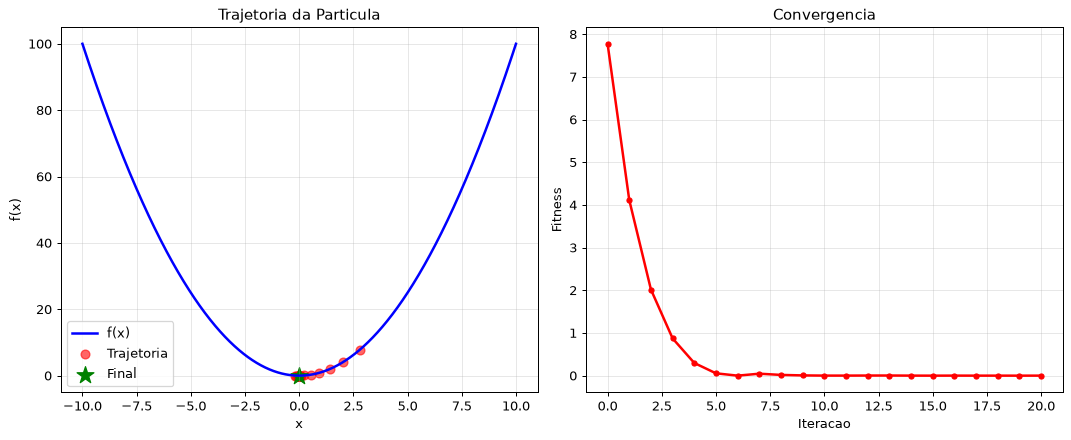

In [2]:
resultado_m1 = missao1()

 MISSAO 2 - PSO - FUNCAO DE ROSENBROCK
Inicio: Melhor fitness = 2.923820
Iteracao  10: Melhor = 0.005174
Iteracao  20: Melhor = 0.002043
Iteracao  30: Melhor = 0.002043
Iteracao  40: Melhor = 0.001536
Iteracao  50: Melhor = 0.001518

Fim: Melhor fitness = 0.001518
Otimo global: f(1,1) = 0.000000


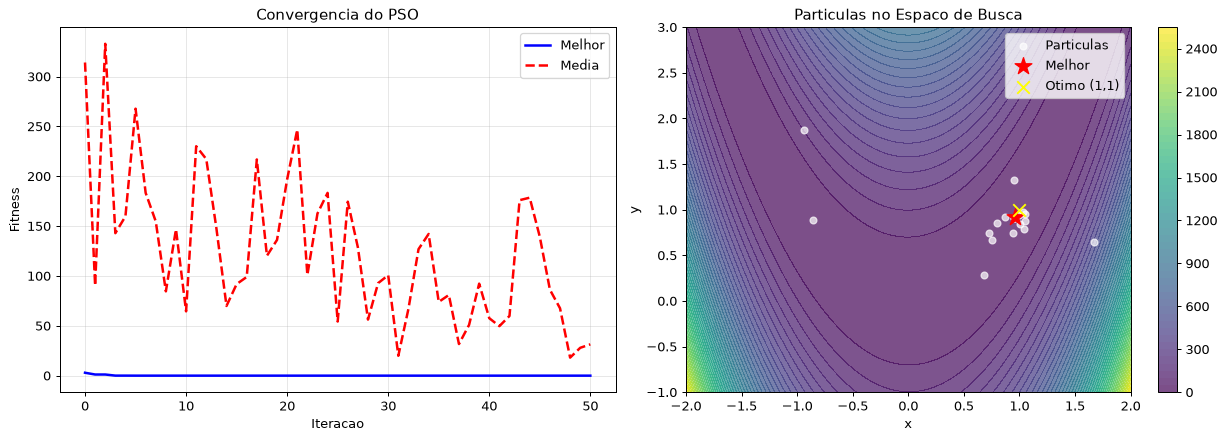

In [3]:
resultado_m2 = missao2()

 MISSAO 3 - OPTIMUS TECH - LOGISTICA INTELIGENTE

 DADOS DO PROBLEMA:
   - 50 clientes
   - 5 centros de distribuicao
   - Demanda media: 51.0 unidades

 OTIMIZANDO...
  Iteracao  20: Custo = 3716.12
  Iteracao  40: Custo = 3581.58
  Iteracao  60: Custo = 3526.28
  Iteracao  80: Custo = 3517.56
  Iteracao 100: Custo = 3514.93

 RESULTADO FINAL:
   Tempo de execucao: 1.69 segundos
   Custo total: 3514.93
   Melhor custo possivel: 0.00
   Centros de distribuicao:
      Centro 1: (2.70, 5.32)
      Centro 2: (0.59, 8.65)
      Centro 3: (5.47, 1.76)
      Centro 4: (0.90, 1.94)
      Centro 5: (7.74, 6.12)


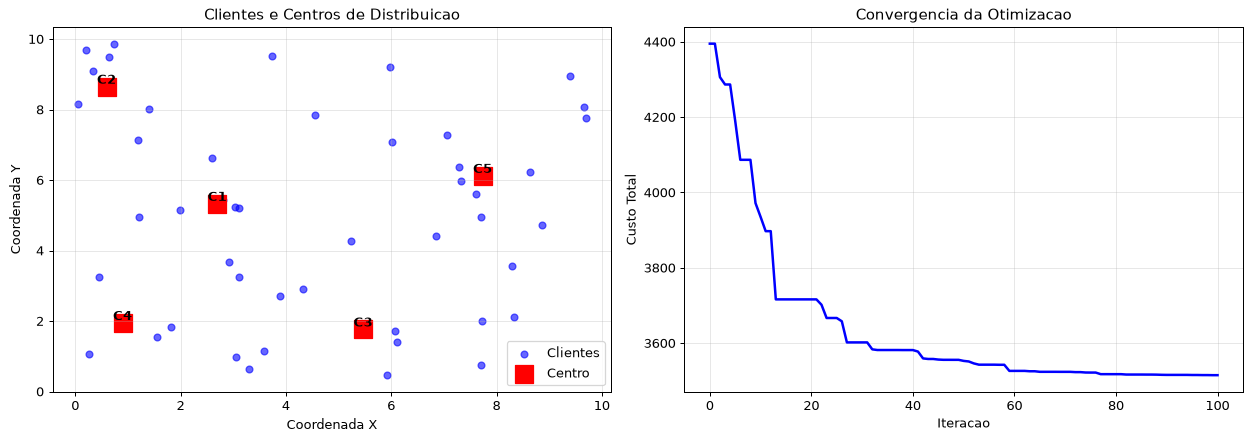

In [4]:
resultado_m3 = missao3()

 MISSAO 4 - EXPERIMENTOS COM PARAMETROS DO PSO

 Experimento: Padrao
   Parametros: w=0.7, c1=1.8, c2=1.8, particulas=30
   Custo medio: 3638.88 +/- 73.07

 Experimento: Inercia Alta
   Parametros: w=0.9, c1=1.8, c2=1.8, particulas=30
   Custo medio: 3951.15 +/- 139.29

 Experimento: Inercia Baixa
   Parametros: w=0.5, c1=1.8, c2=1.8, particulas=30
   Custo medio: 3647.04 +/- 91.90

 Experimento: Cognitivo Alto
   Parametros: w=0.7, c1=2.5, c2=1.8, particulas=30
   Custo medio: 3750.04 +/- 55.77

 Experimento: Social Alto
   Parametros: w=0.7, c1=1.8, c2=2.5, particulas=30
   Custo medio: 3952.36 +/- 67.52

 Experimento: Mais Particulas
   Parametros: w=0.7, c1=1.8, c2=1.8, particulas=60
   Custo medio: 3635.02 +/- 57.41

 ANALISE DOS RESULTADOS

| Experimento        | Custo Medio | Melhor Custo | Pior Custo  |
|--------------------|-------------|--------------|-------------|
| Padrao             |    3638.88 |      3547.08 |     3712.66 |
| Inercia Alta       |    3951.15 |      3772.

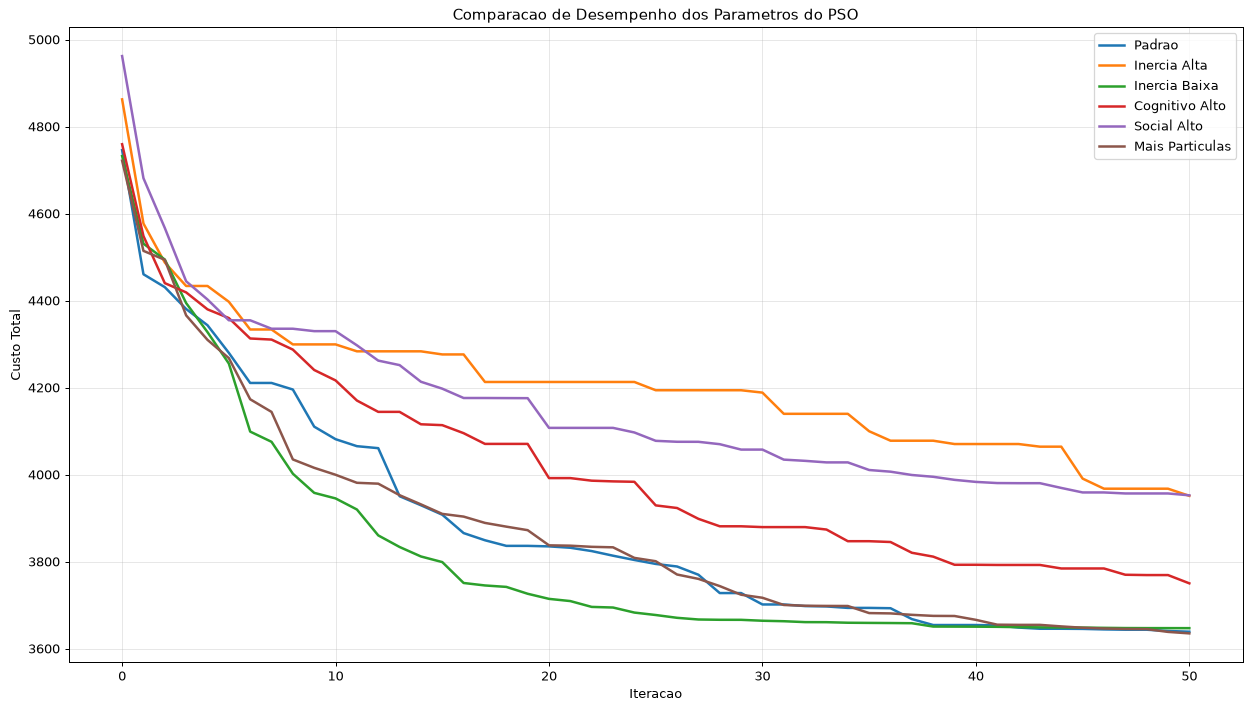


 ANALISE E CONCLUSOES

1. Qual configuracao obteve o MELHOR resultado?
   -> Mais Particulas

2. Qual configuracao obteve o PIOR resultado?
   -> Social Alto


In [5]:
resultado_m4 = missao4()

In [6]:
print("\n\n" + "#" * 60)
print("# RESUMO GERAL - TODAS AS MISSOES CONCLUIDAS")
print("#" * 60)
print(f"Missao 1 - Erro final (particula solitaria): {abs(resultado_m1['posicao_final']):.6f}")
print(f"Missao 2 - Melhor fitness (Rosenbrock)      : {resultado_m2['best_fit']:.6f}")
print(f"Missao 3 - Custo total logistico            : {resultado_m3['custo_final']:.2f}")
print(f"Missao 4 - Melhor configuracao de parametros: {resultado_m4['melhor']}")



############################################################
# RESUMO GERAL - TODAS AS MISSOES CONCLUIDAS
############################################################
Missao 1 - Erro final (particula solitaria): 0.027285
Missao 2 - Melhor fitness (Rosenbrock)      : 0.001518
Missao 3 - Custo total logistico            : 3514.93
Missao 4 - Melhor configuracao de parametros: Mais Particulas
